# **Projeto de Análise Exploratória de Dados: Impacto do COVID-19 na inserção e desempenho no ENEM - AM sob uma visão socioeconômica**

## 1 - Introdução e contexto

Projeto de Análise Exploratória de Dados visando compreender como o ínicio, auge, decorrer e pós-crise da pandemia afetou o desempenho dos estudantes do ENEM em Amazonas, mantendo também uma lente socioeconômica para encontrar dificuldades enfrentadas por alunos em situações de vulnerabilidade econômica. 

Antes de seguir para a análise, é necessário entender o porque da escolha de investigar este estado em específico: o Amazonas apresentou um dos cenários mais críticos do país em uma relação de casos por habitantes, datando em maio de 2020 como havendo 12 cidades entre as 20 com maior incidências de casos do COVID-19 no Brasil, e registrando ser o estado com maior taxa de mortalidade datando abril de 2021. Neste ponto há de se lembrar da crise do oxigênio em Manaus, em janeiro de 2021, devido à alta demanda frente aos aumentos constantes em números de casos. Este contexto é necessário para nos permitir observar as vulnerabilidades do ensino público perante estas informações.

## 2 - Dicionário de Dados

| Coluna | Descrição | Tipo | Observações |
| :--- | :--- | :--- | :--- |
| NU_INSCRICAO | Inscrição do Aluno | Int |
| NU_ANO | Ano de referência da edição do ENEM | Int | Período de 2019 a 2023 |
| TP_ESCOLA | Tipo da escola (Pública/Privada/Sem informação) | Str |
| SG_UF_PROVA | Unidade Federativa onde a prova foi realizada | Str | Filtrado exclusivamente para AM
| TP_PRESENCA_LC | Se houve presença ou falta no primeiro dia | Int | 
| TP_PRESENCA_MT | Se houve presença ou falta no segundo dia | Int |
| NU_NOTA_CN | Nota na matéria Ciências da Natureza e suas Tecnologias | Float | 
| NU_NOTA_CH | Nota na matéria Ciências Humanas e suas Tecnologias | Float |
| NU_NOTA_LC | Nota na matéria Linguagens, Códigos e suas Tecnologias | Float |
| NU_NOTA_MT | Nota na matéria Matemática e suas Tecnologias | Float |
| NU_NOTA_REDACAO | Nota na Redação | Float
| Q006 | Renda do aluno | Str | Mais abaixo no código é agrupada em 'Baixa renda', 'Média renda' e 'Alta renda' |
| Q025 | Se o aluno possuía acesso à internet | Str |

## 3 - Metodologia

**Fonte**: Utlização dos Microdados oficias do ENEM (edições de 2019 a 2023), disponibilizados pelo INEP.

**Filtragem**: Por conta da magnitude do dataset nacional, foi realizado a filtragem para extrair exclusivamente os dados dos candidatos que realizaram a prova no Amazonas, permitindo uma análise também focada na crise vivida pelo estado em 2021.

**Tratamento de Dados**: Criação de funções para a renomeação de colunas para obtermos termos mais légiveis e facilitar a manutenção do código; Mapeamento de renda (Baixa renda, Média renda e Alta renda) com a criação da variável Renda_Familiar e tipo de escola (pública, privada ou sem informação) com a variável Tipo_Escola; além disso, houve o tratamento e limpeza de dados nulos para evitar distorção na análise de desempenho.


## 4 - Configuração do ambiente e tratamento de dados

In [120]:
import pandas as pd

#libs para visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

anos = [2019, 2020, 2021, 2022, 2023]
lista_dfs = []

#criação de um DataFrame único com os dados de todos os anos, usando concatenação
for ano in anos:
    arquivo = f'dados_ENEM_AM_{ano}.csv'
    print(f'Lendo: {arquivo}')

    df_temporario = pd.read_csv(arquivo)
    lista_dfs.append(df_temporario)


df = pd.concat(lista_dfs, ignore_index=True)

Lendo: dados_ENEM_AM_2019.csv
Lendo: dados_ENEM_AM_2020.csv
Lendo: dados_ENEM_AM_2021.csv
Lendo: dados_ENEM_AM_2022.csv
Lendo: dados_ENEM_AM_2023.csv


In [121]:
df.columns

Index(['NU_INSCRICAO', 'NU_ANO', 'TP_ESCOLA', 'SG_UF_PROVA', 'TP_PRESENCA_LC',
       'TP_PRESENCA_MT', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC',
       'NU_NOTA_MT', 'NU_NOTA_REDACAO', 'Q006', 'Q025'],
      dtype='str')

In [122]:
#Usando funções para renomear colunas e facilitar a manipulação dos dados

colunas_renomeadas = {
    'NU_ANO' : 'Ano',
    'TP_ESCOLA' : 'Tipo_Escola',
    'TP_PRESENCA_LC' : 'Presenca_Dia_1',
    'TP_PRESENCA_MT' : 'Presenca_Dia_2',
    'NU_NOTA_CN' : 'Nota_Ciencias_Natureza',
    'NU_NOTA_CH' : 'Nota_Ciencias_Humanas',
    'NU_NOTA_LC' : 'Nota_Linguagens_Codigos',
    'NU_NOTA_MT' : 'Nota_Matematica',
    'NU_NOTA_REDACAO' : 'Nota_Redacao',
    'Q006' : 'Renda_Familiar',
    'Q025' : 'Acesso_Internet'
}

df = df.rename(columns=colunas_renomeadas)

def editar_escola (tipo):
    if tipo == 1:
        return 'Sem Informações'
    elif tipo == 2:
        return 'Pública'
    elif tipo == 3:
        return 'Privada'
    else:
        return 'Exterior'
    
def editar_renda (renda):
    if renda == 'A' or renda == 'B' or renda == 'C':
        return 'Baixa renda'
    elif renda == 'D' or renda == 'E' or renda == 'F' or renda == 'G' or renda == 'H':
        return 'Média renda'
    else:
        return 'Alta renda'
    
def editar_internet (acesso):
    if acesso == 'A':
        return 'Não'
    else:
        return 'Sim'

df['Tipo_Escola'] = df['Tipo_Escola'].apply(editar_escola)
df['Renda_Familiar'] = df['Renda_Familiar'].apply(editar_renda)
df['Acesso_Internet'] = df['Acesso_Internet'].apply(editar_internet)


In [123]:
df.head(5) #Checando as colunas renomeadas

,NU_INSCRICAO,Ano,Tipo_Escola,SG_UF_PROVA,Presenca_Dia_1,Presenca_Dia_2,Nota_Ciencias_Natureza,Nota_Ciencias_Humanas,Nota_Linguagens_Codigos,Nota_Matematica,Nota_Redacao,Renda_Familiar,Acesso_Internet
0,190001082475,2019,Pública,AM,1,1,385.8,436.3,393.8,370.0,260.0,Baixa renda,Sim
1,190001082476,2019,Sem Informações,AM,1,1,454.4,419.2,466.3,441.7,520.0,Média renda,Sim
2,190001082477,2019,Sem Informações,AM,1,1,568.2,546.0,524.9,469.6,580.0,Baixa renda,Sim
3,190001082478,2019,Sem Informações,AM,0,0,NaN,NaN,NaN,NaN,NaN,Média renda,Sim
4,190001082479,2019,Sem Informações,AM,1,1,500.1,506.6,516.6,505.3,560.0,Baixa renda,Sim


## 5 - **Análise de dados e criações gráficas:**

    Hipotéses a serem exploradas neste projeto:

    1 - Houve menos inscrições no ENEM conforme o decorrer da pandemia e crise sanitária em Amazonas?

    2 - Alunos sem acesso à internet enfrentaram uma barreira durante o ENEM que resultou em maior abstenção nas provas comparado a 2019?

    3 - Alunos vindo de famílias de baixa renda e escola pública tiveram uma queda em suas notas conforme o decorrer da pandemia?

    4 - Alunos vindo de famílias de maior renda e escola privada conseguiram manter uma nota estável durante o decorrer da pandemia?

### Hipotése 1: Houve menos inscrições no ENEM conforme o decorrer da pandemia e crise sanitária em Amazonas?

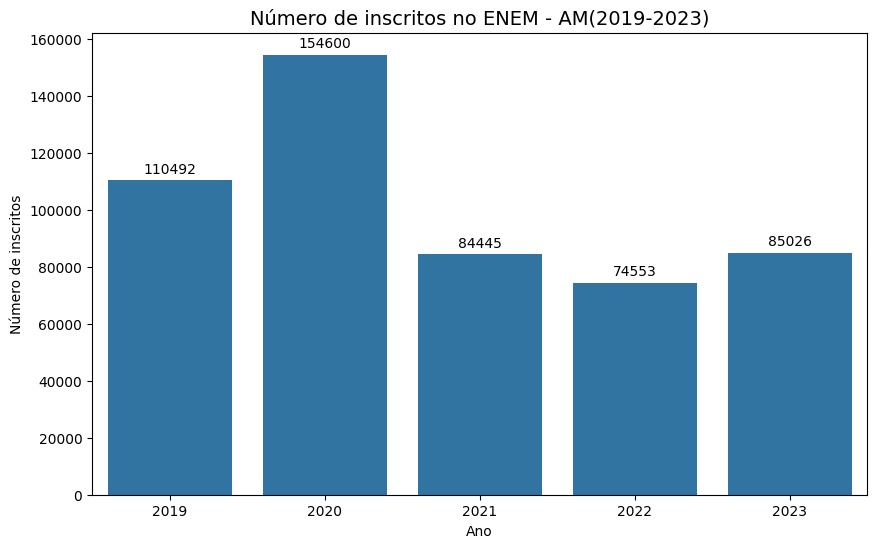

In [124]:
#Contagem de inscrições por ano
inscritos_anos = df['Ano'].value_counts().sort_index().reset_index()
inscritos_anos.columns = ['Ano', 'Número_de_inscritos']

#Criação de gráfico para análise do impacto do COVID-19 nas inscrições do ENEM (AM)
plt.figure(figsize=(10,6))
inscritos_grafico = sns.barplot(data=inscritos_anos, x='Ano', y='Número_de_inscritos')

for i in inscritos_grafico.containers:
    inscritos_grafico.bar_label(i, fmt='%d', padding=3)

plt.title('Número de inscritos no ENEM - AM(2019-2023)', fontsize=14)
plt.xlabel('Ano')
plt.ylabel('Número de inscritos')
plt.show()

In [125]:
#Usando o Pandas para calcular a % de aumento/queda de inscrições em relação a cada ano anterior
#   Ex.: O ano 2020 usa o 2019 para a comparação. O ano 2021 usa o 2020 para a comparação, e assim segue.

contagem_inscritos = df['Ano'].value_counts().sort_index()

variacao_percentual = contagem_inscritos.pct_change() * 100
df_variacao = pd.DataFrame({
    'Total Inscritos': contagem_inscritos,
    'Variação (%)': variacao_percentual
})

print(df_variacao)

      Total Inscritos  Variação (%)
Ano                                
2019           110492           NaN
2020           154600     39.919632
2021            84445    -45.378396
2022            74553    -11.714133
2023            85026     14.047724


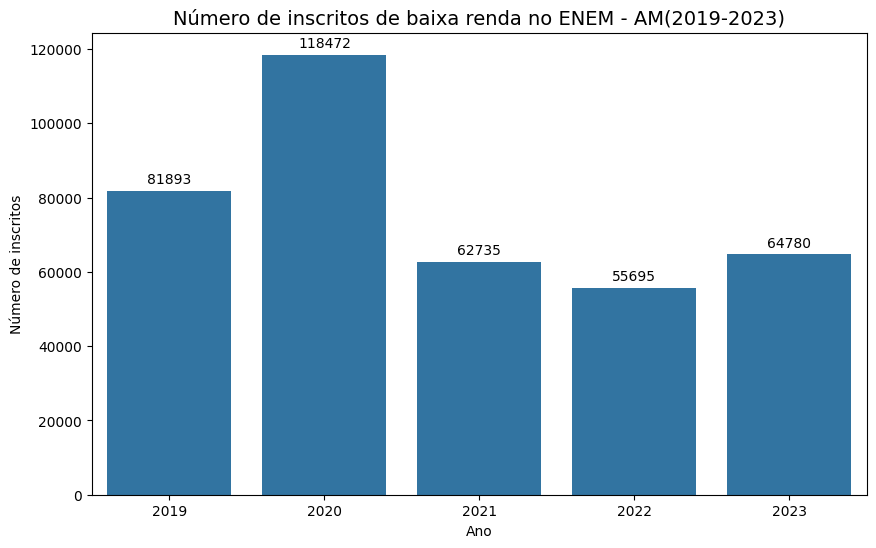

In [126]:
inscritos_baixa_renda = df[df['Renda_Familiar'] == 'Baixa renda'][['Ano','Renda_Familiar']]
inscritos_baixa_renda_ano = inscritos_baixa_renda['Ano'].value_counts().sort_index().reset_index()
inscritos_baixa_renda_ano.columns = ['Ano','Número_de_inscritos']

plt.figure(figsize=(10,6))
inscritos_renda_grafico = sns.barplot(data=inscritos_baixa_renda_ano, x='Ano', y='Número_de_inscritos')

for i in inscritos_renda_grafico.containers:
    inscritos_renda_grafico.bar_label(i, fmt='%d', padding=3)

plt.title('Número de inscritos de baixa renda no ENEM - AM(2019-2023)', fontsize=14)
plt.xlabel('Ano')
plt.ylabel('Número de inscritos')
plt.show()

**Análise da hipotése 1: Impacto de eventos externos em relação ao número de inscrições no ENEM - AM**

    Observações: 

    Houve um aumento de 39.9% de inscritos em 2020, ano que o isolamento começou, em relação a 2019. O fato de que em 2020 houve isenção da taxa de inscrições é relevante neste pico pois removeu a barreira financeira para familias de baixa renda, confirmado pelo gráfico de inscritos filtrado apenas por inscritos de baixa renda onde se consolida o pico de inscrições comparado ao ano anterior.

    Já no começo de 2021 houve uma queda de 45.3% em relação a taxa de inscritos de 2020. Há de se notar que em janeiro deste ano houve a crise do oxigênio em Manaus. Esta tragédia pode ter afetado diretamente os inscritos que haveriam de possivelmente participar da próxima edição do ENEM que abriria inscrições nos meses a seguir, seja por luto, medo ou vulnerabilidades, estas são questões de análise comportamental que há de se estudar mais a fundo buscando dados comportamentais das pessoas durante a pandemia.

Insight: O Amazonas sofreu uma instabilidade nos primeiros 2 anos (2020 - 2021) em relação ao número de inscritos no ENEM, tendo grande influência de fatores externos devido a pandemia, política de isenção de taxa de inscrições e a crise de oxigênio.

### Hipotése 2: Alunos sem acesso à internet enfrentaram uma barreira durante o ENEM que resultou em maior abstenção nas provas comparado a 2019?

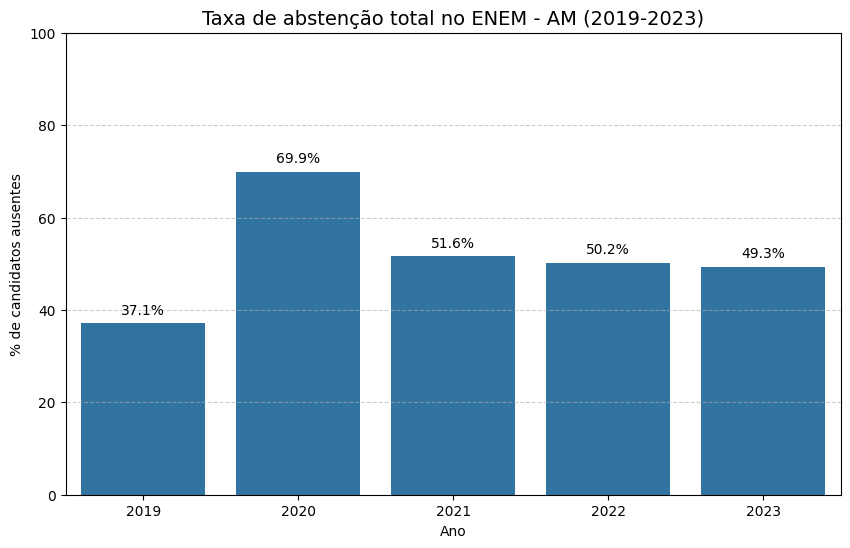

In [127]:
#Criação de gráfico para análise de abstenção total no ENEM (AM) durante a pandemia, usando seaborn e matplotlib

#Presença completa conta como o candidato que compareceu nos dois dias de prova. Abstenção pode ter faltado nos 2 dias, ou só em 1

df['Presenca_Completa'] = ((df['Presenca_Dia_1'] == 1) & (df['Presenca_Dia_2'] == 1)).astype(int)

abstencao = df.groupby('Ano')['Presenca_Completa'].mean().reset_index()
abstencao['Taxa_Abstenção'] = (1 - abstencao['Presenca_Completa']) * 100
plt.figure(figsize=(10,6))
sns.barplot(data=abstencao, x='Ano', y='Taxa_Abstenção')
for i, porcentagem in enumerate(abstencao['Taxa_Abstenção']):
    plt.text(i, porcentagem + 2, f'{porcentagem:.1f}%', ha='center')

plt.ylim(0, 100) #limite do eixo y (% de candidatos ausentes), indo de 0% a 100%
plt.title('Taxa de abstenção total no ENEM - AM (2019-2023)', fontsize=14)
plt.ylabel(f'% de candidatos ausentes')
plt.xlabel('Ano')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

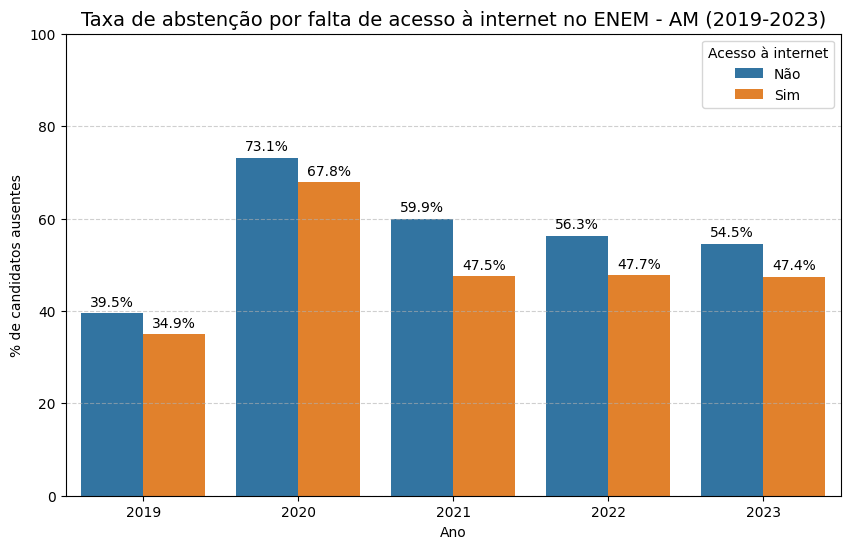

In [128]:
#Gráfico para análise de abstenção por falta de acesso à internet no ENEM (AM) durante a pandemia, com seaborn e matplotlib
abstencao_internet = df.groupby(['Ano', 'Acesso_Internet'])['Presenca_Completa'].mean().reset_index()
abstencao_internet['Taxa_Abstenção'] = (1 - abstencao_internet['Presenca_Completa']) * 100

plt.figure(figsize=(10,6))
abstencao_internet_grafico = sns.barplot(data=abstencao_internet, x='Ano', y='Taxa_Abstenção', hue='Acesso_Internet')
for i in abstencao_internet_grafico.containers:
    abstencao_internet_grafico.bar_label(i, fmt='%.1f%%', padding=3)

plt.ylim(0, 100)
plt.title('Taxa de abstenção por falta de acesso à internet no ENEM - AM (2019-2023)', fontsize=14)
plt.ylabel(f'% de candidatos ausentes')
plt.xlabel('Ano')
plt.legend(title='Acesso à internet')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

**Análise da hipotése 2: Impacto do acesso à internet para a permanência dos estudantes no vestibular.**

    Observações:
    Na primeira hipotése, notamos que a taxa de inscrições em 2020 foi extremamente alta. Entretando, ao observar os dados da taxa de abstenção, nota-se um aumento substantivo em relação ao ano pré-COVID (2019).

    De 100% dos alunos inscritos no ENEM - AM que não possuiam acesso à internet, 73.1% deles faltaram à prova em 2020, aumento drástico em relação aos 39.5% em 2019. Nos 3 anos seguintes, embora haver uma queda ao decorrer da pandemia, a taxa de abstenção destes alunos se manteve constantemente acima de 50%, denunciando uma vulnerabilidade socioeconômica persistente. Há de se observar também que conforme maior o número de inscritos, a taxa de abstenção há de subir proporcionalmente.

Insight: Os dados validam a hipotése de que o acesso à internet foi um fator decisivo para a permanência dos alunos.

### Hipotése 3: Alunos vindo de famílias de baixa renda e escola pública tiveram uma queda em suas notas conforme o decorrer da pandemia comparado a 2019?

In [132]:
#Cálculo da média geral das notas dos candidatos por ano
colunas_notas = [
    'Nota_Ciencias_Natureza',
    'Nota_Ciencias_Humanas',
    'Nota_Linguagens_Codigos',
    'Nota_Matematica',
    'Nota_Redacao'
]

#Filtragem de valores NaN (abstenção na prova) para não interferir na análise
df_notas = df.dropna(subset=colunas_notas).copy()

#Cálculo de média geral dos inscritos que não tiveram nenhuma asbtenção
df_notas['Media_Geral'] = df_notas[colunas_notas].mean(axis=1)
print(df_notas[['Ano','Media_Geral']])

         Ano  Media_Geral
0       2019       369.18
1       2019       460.32
2       2019       537.74
4       2019       517.72
6       2019       490.72
...      ...          ...
509102  2023       518.90
509105  2023       548.10
509106  2023       595.26
509107  2023       372.46
509113  2023       506.68

[237147 rows x 2 columns]


In [134]:
print(f"Total de dados original: {len(df)}")
print(f"Total após remover as notas que contém valor NaN: {len(df_notas)}")

Total de dados original: 509116
Total após remover as notas que contém valor NaN: 237147


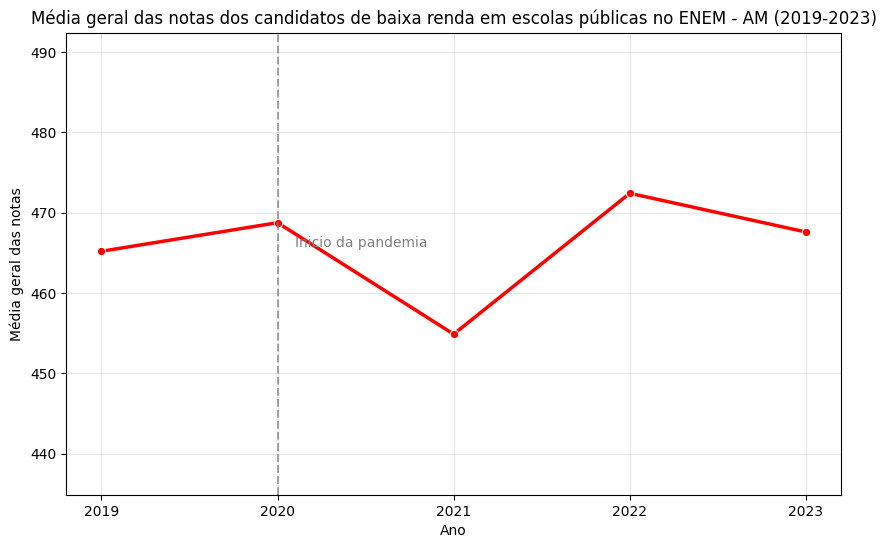

In [135]:
#Filtrando os candidatos de baixa renda que estudam em escolas públicas
filtro_renda_baixa = df_notas[(df_notas['Renda_Familiar'] == 'Baixa renda') & (df_notas['Tipo_Escola'] == 'Pública')] 
renda_baixa_media = filtro_renda_baixa.groupby('Ano')['Media_Geral'].mean().reset_index()

#Criação do gráfico de linhas para a média geral das notas dos candidatos (baixa renda e escola pública)
plt.figure(figsize=(10,6))
sns.lineplot(data=renda_baixa_media, x='Ano', y='Media_Geral', marker='o', color='red', linewidth=2.5)

anos_grafico = renda_baixa_media['Ano'].unique()
plt.xticks(anos_grafico)

plt.axvline(2020, color='gray', linestyle='--', alpha=0.7)

plt.ylim(renda_baixa_media['Media_Geral'].min() - 20, renda_baixa_media['Media_Geral'].max() + 20)
plt.text(2020.1, renda_baixa_media['Media_Geral'].mean(), 'Inicio da pandemia', color='gray')

plt.title('Média geral das notas dos candidatos de baixa renda em escolas públicas no ENEM - AM (2019-2023)', fontsize=12)
plt.ylabel('Média geral das notas')
plt.xlabel('Ano')
plt.grid(True, alpha=0.3)

plt.show()

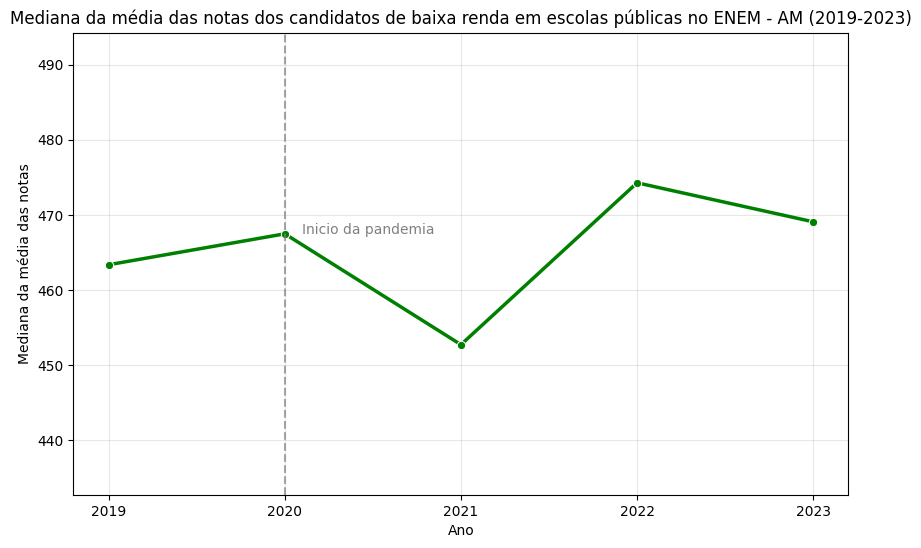

In [136]:
renda_baixa_mediana = filtro_renda_baixa.groupby('Ano')['Media_Geral'].median().reset_index()

#Criação do gráfico de linhas para a MEDIANA da média das notas dos candidatos (baixa renda e escola pública)
plt.figure(figsize=(10,6))
sns.lineplot(data=renda_baixa_mediana, x='Ano', y='Media_Geral', marker='o', color='green', linewidth=2.5)

plt.xticks(anos_grafico)

plt.axvline(2020, color='gray', linestyle='--', alpha=0.7)

plt.ylim(renda_baixa_mediana['Media_Geral'].min() - 20, renda_baixa_mediana['Media_Geral'].max() + 20)

plt.text(2020.1, renda_baixa_mediana['Media_Geral'].median(), 'Inicio da pandemia', color='gray')

plt.title('Mediana da média das notas dos candidatos de baixa renda em escolas públicas no ENEM - AM (2019-2023)', fontsize=12)
plt.ylabel('Mediana da média das notas')
plt.xlabel('Ano')
plt.grid(True, alpha=0.3)

plt.show()

In [137]:
renda_baixa_media


,Ano,Media_Geral
0,2019,465.198791
1,2020,468.762425
2,2021,454.877180
3,2022,472.424136
4,2023,467.602308


In [138]:
renda_baixa_mediana

,Ano,Media_Geral
0,2019,463.36
1,2020,467.48
2,2021,452.71
3,2022,474.28
4,2023,469.08


**Análise da Hipotése 3: O impacto do COVID-19 no desempenho dos candidatos de baixa renda no ENEM**

Ao analisarmos o desempenho dos candidatos de baixa renda em escolas públicas, os gráficos de média e mediana revelam um ponto crítico em 2021 com uma queda significativa na nota. 
Curiosamente, houve também um pequeno aumento no desempenho em 2020, ano do ínicio da pandemia. É possível que nesta época o impacto do isolamento social, falta de acesso à internet e das aulas à distância ainda não haviam se consolidado.

Observa-se uma retomada do desempenho a partir de 2022, apresentando uma certa estabilidade em 2023.

Insight: Os dados mostram que 2021 foi o ano de maior impacto negativo aos alunos do ENEM - AM durante a pandemia, coincidindo a queda das notas com a crise do oxigênio enfrentada no começo do ano e reforçando o impacto que este teve nos alunos.

### Hipotése 4: Alunos vindo de famílias de maior renda e escola privada conseguiram manter uma nota estável durante o decorrer da pandemia?

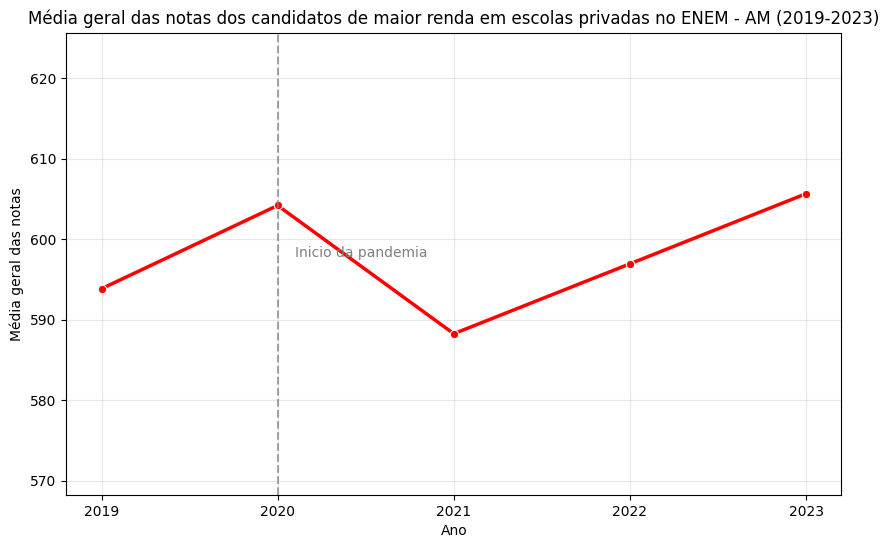

In [139]:
#Filtrando os candidatos que não são de baixa renda e que estudam em escolas privadas
filtro_escola_privada = df_notas[(df_notas['Renda_Familiar'] != 'Baixa renda') & (df_notas['Tipo_Escola'] == 'Privada')] 
escola_privada_media = filtro_escola_privada.groupby('Ano')['Media_Geral'].mean().reset_index()

#Criação do gráfico de linhas para a média geral das notas dos candidatos (maior renda e escola privada)
plt.figure(figsize=(10,6))
sns.lineplot(data=escola_privada_media, x='Ano', y='Media_Geral', marker='o', color='red', linewidth=2.5)

anos_grafico_privada = escola_privada_media['Ano'].unique()
plt.xticks(anos_grafico_privada)

plt.axvline(2020, color='gray', linestyle='--', alpha=0.7)

plt.ylim(escola_privada_media['Media_Geral'].min() - 20, escola_privada_media['Media_Geral'].max() + 20)
plt.text(2020.1, escola_privada_media['Media_Geral'].mean(), 'Inicio da pandemia', color='gray')

plt.title('Média geral das notas dos candidatos de maior renda em escolas privadas no ENEM - AM (2019-2023)', fontsize=12)
plt.ylabel('Média geral das notas')
plt.xlabel('Ano')
plt.grid(True, alpha=0.3)

plt.show()

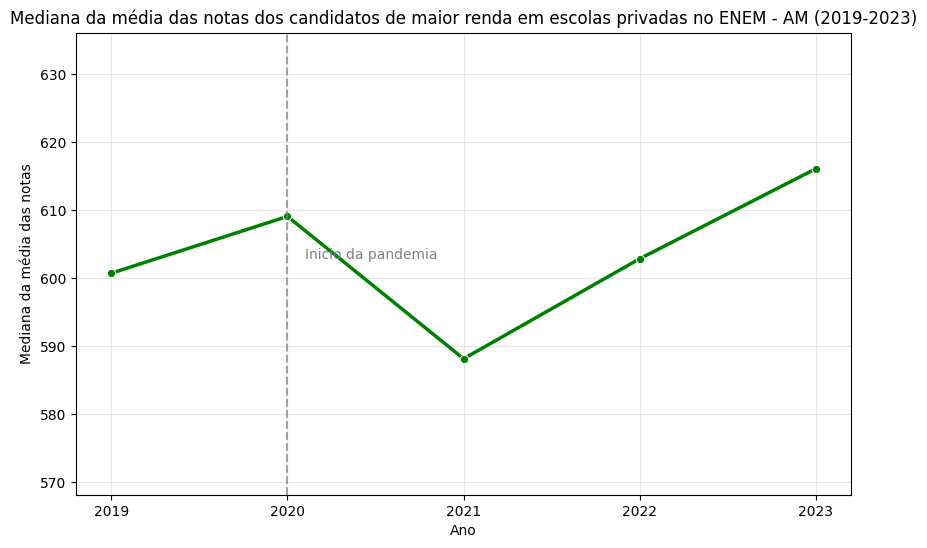

In [ ]:
escola_privada_mediana = filtro_escola_privada.groupby('Ano')['Media_Geral'].median().reset_index()

#Criação do gráfico de linhas para a MEDIANA da média das notas dos candidatos (maior renda e escola privada)
plt.figure(figsize=(10,6))
sns.lineplot(data=escola_privada_mediana, x='Ano', y='Media_Geral', marker='o', color='green', linewidth=2.5)

plt.xticks(anos_grafico_privada)

plt.axvline(2020, color='gray', linestyle='--', alpha=0.7)

plt.ylim(escola_privada_mediana['Media_Geral'].min() - 20, escola_privada_mediana['Media_Geral'].max() + 20)

plt.text(2020.1, escola_privada_mediana['Media_Geral'].median(), 'Inicio da pandemia', color='gray')

plt.title('Mediana da média das notas dos candidatos de maior renda em escolas privadas no ENEM - AM (2019-2023)', fontsize=12)
plt.ylabel('Mediana da média das notas')
plt.xlabel('Ano')
plt.grid(True, alpha=0.3)

plt.show()

In [141]:
escola_privada_media

,Ano,Media_Geral
0,2019,593.861872
1,2020,604.206834
2,2021,588.273676
3,2022,596.957090
4,2023,605.665730


In [142]:
escola_privada_mediana

,Ano,Media_Geral
0,2019,600.75
1,2020,609.10
2,2021,588.16
3,2022,602.88
4,2023,616.12


**Análise da Hipotése 4:**

Assim como o grupo de baixa renda em escola pública, observa-se uma grande queda na nota em 2021, mostrando um impacto universal da crise de 2021 e segundo ano da pandemia e isolamento social. É interessante observar que a nota da média geral e da mediana da média geral é quase a mesma, sugerindo que a queda no desempenho não foi um fator causado por alguns alunos tirando nota muito baixa mas sim uma baixa no desempenho geral de todo o grupo.

Este grupo também demonstrou uma recuperação mais consistente com aumento constante na média e mediana, diferente do grupo de baixa renda em escola pública onde houve um aumento das notas em 2022 seguido duma queda em 2023.

Conclue-se que, embora a crise de 2021 tenha afetado os dois grupos, a estrutura das escolas privadas permitiu uma retomada mais consistente no desempenho.

## 6 - Conclusão

Esta análise exploratória de dados evidenciou que o desempenho e volume de inscritos no ENEM - AM durante o decorrer da pandemia foi claramente moldado por fatores externos. O pico de 2020 mostrou a eficácia e impacto positivo da política de isenção, enquanto a queda de 2021 expôs a fragilidade do sistema educacional diante de tragédias e crises, afetando candidatos de todas as classes sociais. A discrepância na recuperação do desempenho pós 2021 entre os sistemas educionais público e privado relevou a vulnerabilidade do sistema educacional público que requer mais atenção de políticas públicas para manutenção e cuidado diante de tragédias e adversidades. 

## 7 - Referências

**Dados Oficias:**

INEP – Instituto Nacional de Estudos e Pesquisas Educacionais Anísio Teixeira. Microdados do ENEM (2019, 2020, 2021, 2022, 2023). Disponível em: ([gov.br/inep](https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/microdados)).

FVS-RCP/AM – Fundação de Vigilância em Saúde do Amazonas. Painel Epidemiológico: Monitoramento COVID-19 no Amazonas. Disponível em:
([fvs.am.gov.br](https://www.fvs.am.gov.br/indicadorSalaSituacao_view/60/2)).

MEC – Ministério da Educação. Ações do Ministério da Educação no combate ao Coronavírus. Disponível em: ([portal.mec.gov.br/coronavirus](https://portal.mec.gov.br/coronavirus/)).


**Artigos Científicos e Analíses Acadêmicas:**

ORELLANA, Jesem et al. Explosão da mortalidade no epicentro amazônico da epidemia de COVID-19. Disponível em: ([scielosp.org](https://www.scielosp.org/article/csp/2020.v36n7/e00120020/pt/#)).


**Reportagens e Contexto Histórico:**

G1 AM. Amazonas tem 12 cidades entre as 20 com maior incidências de casos de Covid-19 no Brasil. (Maio/2020). Disponível em: ([g1.globo.com/am](https://g1.globo.com/am/amazonas/noticia/2020/05/05/amazonas-tem-12-cidades-entre-as-20-com-maior-incidencias-de-casos-de-covid-19-no-brasil.ghtml)).

G1 AM. O dia em que faltou ar: crise do oxigênio em Manaus completa cinco anos. (Janeiro/2026). Disponível em: ([g1.globo.com/am](https://g1.globo.com/am/amazonas/noticia/2026/01/14/o-dia-em-que-faltou-ar-crise-do-oxigenio-em-manaus-completa-cinco-anos.ghtml)).

BBC NEWS BRASIL. Muita chuva, poucos testes e mais gente na rua: o que levou Amazonas a explosão de casos de covid-19. (Abril/2020). Disponível em: ([bbc.com](https://www.bbc.com/portuguese/brasil-52333611)).

Amazonas atual. Amazonas é o estado com a maior taxa de mortalidade desde o início da pandemia. (Abril/2021). Disponível em: ([amazonasatual.com.br](https://amazonasatual.com.br/amazonas-e-o-estado-com-a-maior-taxa-de-mortalidade-desde-o-inicio-da-pandemia/)).


**Bibiotecas usadas:**

Pandas: ([pandas.pydata.org](https://pandas.pydata.org/)).

Seaborn: ([seaborn.pydata.org](https://seaborn.pydata.org/)).

Matplotlib: ([matplotlib.org](https://matplotlib.org/)).
